# Notebook 6 — GRU Classifier

## Objective

Train a GRU-based binary classifier on the FFT-filtered dataset produced
by Notebook 5. This notebook performs **classification only** — it does
not regenerate FFT filtering, TimeGAN synthesis, or labels.

This notebook is intentionally thin: all logic lives in
`src/classifier/` (`dataset.py`, `model.py`, `train.py`, `evaluate.py`).
The notebook only wires those modules together, matching the structure
of Notebooks 4 and 5.

### What this notebook does

1. Load `models/train_sequences_fft.npy` and `models/train_labels.npy`.
2. Stratified train / validation / test split.
3. Build a GRU classifier (Input -> GRU -> Dropout -> GRU -> Dense -> Sigmoid,
   with a small Dense head added -- see `src/classifier/model.py` for the
   full architecture rationale).
4. Train with EarlyStopping, ReduceLROnPlateau and ModelCheckpoint,
   saving the best model to `models/gru_classifier.keras`.
5. Evaluate on the held-out test set: accuracy, precision, recall, F1,
   ROC-AUC, confusion matrix, classification report, and training /
   ROC curves.

**This notebook does not modify Notebooks 1-5 or the TimeGAN
implementation.**

## Cell 1 — Imports & Reproducibility

`random`, `numpy` and `tensorflow`/`keras` are all explicitly seeded from
a single `SEED` constant. This matters here specifically because GRU
weight initialization, dropout masks, and the Adam optimizer's internal
state are all stochastic — without fixing all three seeds, re-running
this notebook could produce a different model (and therefore different
reported metrics) even on identical data.

In [1]:
import random
import sys
from pathlib import Path

import numpy as np
import tensorflow as tf

# Make src/ importable (notebook lives in notebooks/, src/ is a sibling of it).
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from classifier.dataset import load_fft_dataset, stratified_split
from classifier.model import build_gru_classifier
from classifier.train import get_callbacks, train_model
from classifier.evaluate import (
    compute_metrics,
    print_classification_report,
    plot_training_curves,
    plot_confusion_matrix,
    plot_roc_curve,
)

# Reproducibility: fix every source of randomness this notebook touches
# (Python's random module, NumPy, and TensorFlow/Keras).
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)


TensorFlow: 2.21.0
Keras: 3.15.0
GPU available: False


## Cell 2 — Load Notebook 5 Output

Loads `train_sequences_fft.npy` and `train_labels.npy`. `load_fft_dataset`
raises a clear error if Notebook 5 has not been run yet.

### Why FFT-denoised sequences are used here

This notebook deliberately trains on the FFT low-pass-filtered sequences
produced by Notebook 5, not the raw consumption sequences. The low-pass
filter suppresses high-frequency meter noise and one-off misreads while
preserving the low-frequency, sustained behavioural patterns that
distinguish theft from honest consumption. Feeding the GRU a
higher-signal-to-noise input reduces the risk of the network fitting to
noise rather than genuine consumption behaviour, which is especially
important here since part of the theft class is TimeGAN-synthesized and
therefore already at some risk of carrying generator-specific artefacts.

In [2]:
MODELS_DIR = PROJECT_ROOT / "models"

try:
    X, y = load_fft_dataset(
        sequences_path=MODELS_DIR / "train_sequences_fft.npy",
        labels_path=MODELS_DIR / "train_labels.npy",
    )
except FileNotFoundError as e:
    print("=" * 60)
    print("ERROR: Required input file(s) not found.")
    print("=" * 60)
    print(e)
    print()
    print("-> Please run Notebook 5 (FFT preprocessing) first and "
          "confirm it has saved train_sequences_fft.npy and "
          "train_labels.npy into the models/ folder before running "
          "Notebook 6.")
    raise

SEQ_LEN = X.shape[1]
N_FEATURES = X.shape[2]

print("Sequences shape:", X.shape)
print("Labels shape   :", y.shape)
print("Sequence length (T):", SEQ_LEN, "| Features:", N_FEATURES)
print("Class balance -> Honest (0):", int((y == 0).sum()), "| Theft (1):", int((y == 1).sum()))


Sequences shape: (42472, 1033, 1)
Labels shape   : (42472,)
Sequence length (T): 1033 | Features: 1
Class balance -> Honest (0): 38757 | Theft (1): 3715


## Cell 3 — Stratified Train / Validation / Test Split

70% train / 15% validation / 15% test, stratified on the label at each
split so the honest/theft ratio is preserved across all three sets —
important since class balance affects threshold-sensitive metrics like
precision and recall.

### Why stratified splitting is important

An ordinary random split can, by chance, leave the validation or test
set with a noticeably different honest/theft ratio than the full
dataset — especially with a two-class problem where one class is
augmented with synthetic samples. That shift would bias validation-based
decisions (early stopping, learning-rate reduction, checkpoint
selection) and make the final test metrics harder to compare across
runs. Stratifying on the label at every split guarantees the honest/theft
ratio is preserved in train, validation and test, so differences in
metrics between runs reflect genuine model behaviour rather than an
accidental difference in class balance.

In [3]:
VAL_SIZE = 0.15
TEST_SIZE = 0.15

splits = stratified_split(X, y, val_size=VAL_SIZE, test_size=TEST_SIZE, seed=SEED)

print(f"Train : {splits.X_train.shape} | theft ratio: {splits.y_train.mean():.3f}")
print(f"Val   : {splits.X_val.shape} | theft ratio: {splits.y_val.mean():.3f}")
print(f"Test  : {splits.X_test.shape} | theft ratio: {splits.y_test.mean():.3f}")

Train : (29730, 1033, 1) | theft ratio: 0.087
Val   : (6371, 1033, 1) | theft ratio: 0.087
Test  : (6371, 1033, 1) | theft ratio: 0.087


## Cell 4 — Build the GRU Classifier

Input -> GRU(64, return_sequences=True) -> Dropout -> GRU(32) ->
Dense(16, relu) -> Dropout -> Dense(1, sigmoid).

See `src/classifier/model.py` for the full rationale behind GRU over
LSTM, the two-layer stack, and the small dense head added on top of the
suggested architecture.

### Why GRU was selected instead of LSTM

GRUs use two gates (reset and update) instead of the three gates
(input, forget, output) and separate cell state used by LSTMs. This
gives a GRU noticeably fewer parameters than an LSTM of the same hidden
size, while empirically reaching comparable accuracy on most
sequence-classification tasks. With sequences of `T = 1033` timesteps,
that parameter saving translates directly into faster training and
lower memory usage — a meaningful benefit for an academic pipeline that
needs to be re-run repeatedly during development and evaluation, without
a meaningful accuracy trade-off for this task.

In [4]:
model = build_gru_classifier(
    seq_len=SEQ_LEN,
    n_features=N_FEATURES,
    gru_units=(64, 32),
    dropout_rate=0.3,
    dense_units=16,
    learning_rate=1e-3,
    seed=SEED,
)

model.summary()

Model: "gru_theft_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ consumption_sequence            │ (None, 1033, 1)        │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 1033, 64)       │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1033, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ theft_probability (Dense)       │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,817 (89.13 KB)

 Trainable params: 22,817 (89.13 KB)

 Non-trainable params: 0 (0.00 B)

## Cell 5 — Train

EarlyStopping, ReduceLROnPlateau and ModelCheckpoint all monitor
validation loss. The best-performing checkpoint (lowest `val_loss`) is
saved to `models/gru_classifier.keras`.

### Why EarlyStopping and ReduceLROnPlateau are used

`EarlyStopping` stops training once validation loss stops improving for
`es_patience` epochs and restores the best-performing weights, which
protects against overfitting to the training set (including
TimeGAN-specific artefacts in the synthetic theft samples) and removes
the need to guess a fixed number of epochs in advance. `ReduceLROnPlateau`
lowers the learning rate when validation loss plateaus, which lets
training take large steps early on and finer steps as it approaches a
minimum — this typically improves final convergence compared to a single
fixed learning rate for the whole run. Both callbacks monitor the same
metric (`val_loss`), so their behaviour stays consistent with each
other and with the checkpointing criterion.

In [6]:
CHECKPOINT_PATH = MODELS_DIR / "gru_classifier.keras"
EPOCHS = 20
BATCH_SIZE = 32

callbacks = get_callbacks(
    checkpoint_path=CHECKPOINT_PATH,
    es_patience=10,
    rlr_patience=5,
)

history = train_model(
    model,
    splits.X_train, splits.y_train,
    splits.X_val, splits.y_val,
    callbacks=callbacks,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

# Save the training history so results can be re-plotted later without
# re-running training (Change 5 — reproducibility / Notebook 7 usage).
import pickle

HISTORY_PATH = MODELS_DIR / "training_history.pkl"
with open(HISTORY_PATH, "wb") as f:
    pickle.dump(history.history, f)

print("Saved training history:", HISTORY_PATH)


Epoch 1/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.9126 - auc: 0.5492 - loss: 0.2958 - precision: 0.5125 - recall: 0.0158
Epoch 1: val_loss improved from None to 0.28360, saving model to /Users/manavagrawal/Documents/Smart-grid-theft-detection/models/gru_classifier.keras

Epoch 1: finished saving model to /Users/manavagrawal/Documents/Smart-grid-theft-detection/models/gru_classifier.keras
930/930 ━━━━━━━━━━━━━━━━━━━━ 380s 408ms/step - accuracy: 0.9126 - auc: 0.5492 - loss: 0.2958 - precision: 0.5125 - recall: 0.0158 - val_accuracy: 0.9138 - val_auc: 0.6667 - val_loss: 0.2836 - val_precision: 0.6818 - val_recall: 0.0269 - learning_rate: 0.0010
Epoch 2/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9143 - auc: 0.6006 - loss: 0.2867 - precision: 0.7281 - recall: 0.0319
Epoch 2: val_loss improved from 0.28360 to 0.27341, saving model to /Users/manavagrawal/Documents/Smart-grid-theft-detection/models/gru_classifier.keras

Epoch 2: finished saving model to /User

## Cell 6 — Training Curves

Accuracy and loss, train vs. validation, across all completed epochs.

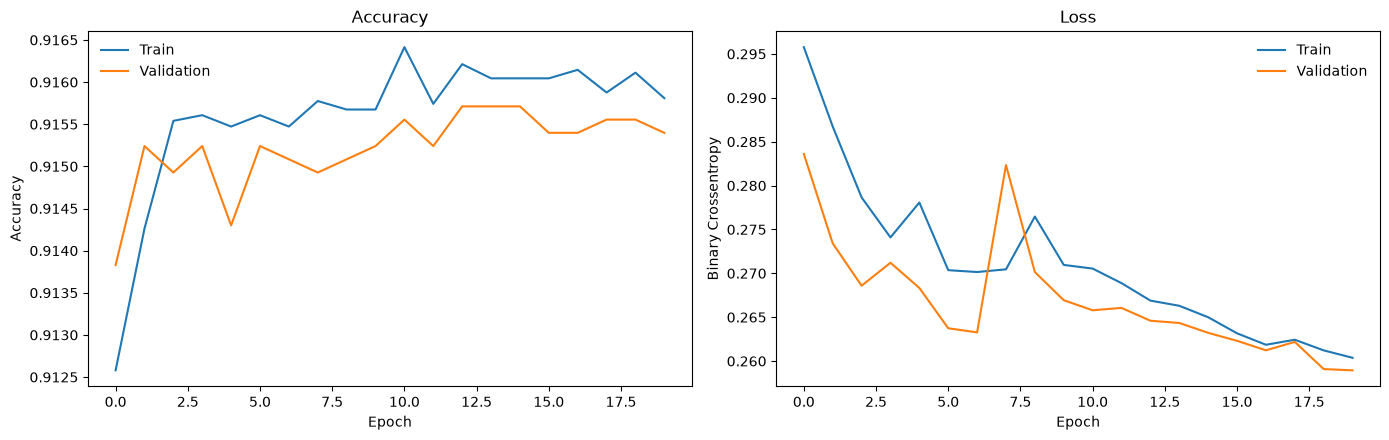

In [7]:
plot_training_curves(history)

## Cell 7 — Load Best Checkpoint & Predict on Test Set

Reloads the best-performing checkpoint from disk (rather than trusting
in-memory weights) so evaluation reflects exactly what is saved to
`models/gru_classifier.keras`.

In [8]:
best_model = tf.keras.models.load_model(CHECKPOINT_PATH)

y_test_prob = best_model.predict(splits.X_test, batch_size=BATCH_SIZE, verbose=1).reshape(-1)
print("Predicted probability range:", y_test_prob.min(), "-", y_test_prob.max())

200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step
Predicted probability range: 0.009934171 - 0.9996178


## Cell 8 — Test Set Metrics

Accuracy, Precision, Recall, F1 and ROC-AUC at the default 0.5
threshold, plus the full sklearn classification report broken down by
class.

In [9]:
metrics = compute_metrics(splits.y_test, y_test_prob, threshold=0.5)
print(metrics)
print()
print_classification_report(splits.y_test, y_test_prob, threshold=0.5)

Accuracy  : 0.9157
Precision : 0.7778
Recall    : 0.0503
F1 Score  : 0.0944
ROC-AUC   : 0.7452

              precision    recall  f1-score   support

  Honest (0)       0.92      1.00      0.96      5814
   Theft (1)       0.78      0.05      0.09       557

    accuracy                           0.92      6371
   macro avg       0.85      0.52      0.53      6371
weighted avg       0.90      0.92      0.88      6371



## Cell 8b — Save Predictions

Saves the test-set predictions and predicted probabilities to `models/`
so Notebook 7 (and any further analysis) can reuse them without
reloading the model or re-running inference.

In [10]:
import numpy as np

y_test_pred = (y_test_prob >= 0.5).astype(int)

PREDICTIONS_PATH = MODELS_DIR / "predictions.npy"
PROBABILITIES_PATH = MODELS_DIR / "prediction_probabilities.npy"

np.save(PREDICTIONS_PATH, y_test_pred)
np.save(PROBABILITIES_PATH, y_test_prob)

print("Saved predictions            :", PREDICTIONS_PATH)
print("Saved prediction probabilities:", PROBABILITIES_PATH)


Saved predictions            : /Users/manavagrawal/Documents/Smart-grid-theft-detection/models/predictions.npy
Saved prediction probabilities: /Users/manavagrawal/Documents/Smart-grid-theft-detection/models/prediction_probabilities.npy


## Cell 9 — Summary

In [13]:
print("=" * 50)
print("Notebook 06 Completed")
print("=" * 50)
print("Test set size        :", len(splits.y_test))
print(metrics)
print("Best model saved to  :", CHECKPOINT_PATH)
print("Training history saved to:", HISTORY_PATH)
print("Predictions saved to :", PREDICTIONS_PATH)
print("Probabilities saved to:", PROBABILITIES_PATH)
print("=" * 50)


Notebook 06 Completed
Test set size        : 6371
Accuracy  : 0.9157
Precision : 0.7778
Recall    : 0.0503
F1 Score  : 0.0944
ROC-AUC   : 0.7452
Best model saved to  : /Users/manavagrawal/Documents/Smart-grid-theft-detection/models/gru_classifier.keras
Training history saved to: /Users/manavagrawal/Documents/Smart-grid-theft-detection/models/training_history.pkl
Predictions saved to : /Users/manavagrawal/Documents/Smart-grid-theft-detection/models/predictions.npy
Probabilities saved to: /Users/manavagrawal/Documents/Smart-grid-theft-detection/models/prediction_probabilities.npy


In [14]:
np.save(MODELS_DIR / "X_train.npy", splits.X_train)
np.save(MODELS_DIR / "X_val.npy", splits.X_val)
np.save(MODELS_DIR / "X_test.npy", splits.X_test)

np.save(MODELS_DIR / "y_train.npy", splits.y_train)
np.save(MODELS_DIR / "y_val.npy", splits.y_val)
np.save(MODELS_DIR / "y_test.npy", splits.y_test)

print("Saved new train/validation/test split.")

Saved new train/validation/test split.


In [15]:
print(np.load(MODELS_DIR / "X_test.npy").shape)

(6371, 1033, 1)
